# try to visualize a LandSat image:

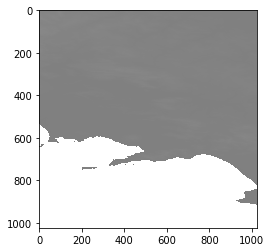

In [2]:
import ee
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request
#import cv2

# Initialize the Earth Engine object, using the authentication credentials.
ee.Initialize()

#region = ee.Geometry.Rectangle(-123, 38.5, -123.01, 38.49)
#data = 'LANDSAT/LC8_L1T/LC80440342014077LGN00'
region = ee.Geometry.Rectangle(14, 40, 15, 42)
data = 'srtm90_v4'

#img = ee.Image(data).visualize(min=0, max=2000, palette=["red", "blue"])
img = ee.Image(data).visualize()

#print(region.toGeoJSON())
#print(img.getInfo())

# remote image
#link = img.getThumbUrl({'dimensions': "1024x1024", 'region': '[[[-120, 30], [-120, 40], [-130, 40], [-130, 30]]]'})
link = img.getThumbUrl({'dimensions': "1024x1024", 'region': region.toGeoJSON()})
#print(link)

rimg = urllib.request.urlopen(link)
#print(rimg)

rimg2 = mpimg.imread( rimg )
plt.imshow(rimg2)
plt.show()

In [5]:
import datetime
import ee
import ee.mapclient

ee.Initialize()
ee.mapclient.centerMap(14.3, 41.5, 5)

# Create a Landsat 7, median-pixel composite for Spring of 2000.
collection = (ee.ImageCollection('LE7_L1T')
              .filterDate(datetime.datetime(2000, 4, 1),
                          datetime.datetime(2000, 7, 1)))
image1 = collection.median()

# Clip to the output image to the California state boundary.
fc = (ee.FeatureCollection('ft:1fRY18cjsHzDgGiJiS2nnpUU3v9JPDc2HNaR7Xk8')
      .filter(ee.Filter().eq('Name', 'Italy')))
image2 = image1.clipToCollection(fc)

# Select the red, green and blue bands.
image = image2.select('B3', 'B2', 'B1')
ee.mapclient.addToMap(image, {'gain': [1.4, 1.4, 1.1]})

NameError: name 'Queue' is not defined

In [65]:
%%javascript

// Load an image.
image = ee.Image('LANDSAT/LC8_L1T/LC80440342014077LGN00');

// Center the map on the image.
Map.centerObject(image, 9);

// Display the image.
Map.addLayer(image);

<IPython.core.display.Javascript object>

In [4]:
import ee
import matplotlib.pyplot as plt

# Initialize the Earth Engine object, using the authentication credentials.
ee.Initialize()

# Load an image.
image = ee.Image('LANDSAT/LC8_L1T/LC80440342014077LGN00');
#image = ee.Image('srtm90_v4')

# Center the map on the image.
#Map.centerObject(image, 9);
# Display the image.
#Map.addLayer(image);

# Print the information for an image asset.
#print(image.size)
#print(image.getInfo())
plt.imshow(image)

TypeError: Image data can not convert to float

In [5]:
import datetime
import ee
import ee.mapclient

ee.Initialize()
ee.mapclient.centerMap(-95.738, 18.453, 9)

# Filter the LE7 collection to a single date.
collection = (ee.ImageCollection('LE7_L1T')
              .filterDate(datetime.datetime(2002, 11, 8),
                          datetime.datetime(2002, 11, 9)))
image = collection.mosaic().select('B3', 'B2', 'B1')

# Display the image normally.
ee.mapclient.addToMap(image, {'gain': '1.6, 1.4, 1.1'}, 'Land')

# Add and stretch the water.  Once where the elevation is masked,
# and again where the elevation is zero.
elev = ee.Image('srtm90_v4')
mask1 = elev.mask().eq(0).And(image.mask())
mask2 = elev.eq(0).And(image.mask())
ee.mapclient.addToMap(
    image.mask(mask1), {'gain': 6.0, 'bias': -200}, 'Water: Masked')
ee.mapclient.addToMap(
    image.mask(mask2), {'gain': 6.0, 'bias': -200}, 'Water: Elev 0')

ImportError: No module named 'cStringIO'

In [6]:
from jupyter_core.paths import jupyter_config_dir
jupyter_dir = jupyter_config_dir()
jupyter_dir

'/Users/giuliano/.jupyter'

In [7]:
import os.path
custom_js_path = os.path.join(jupyter_dir, 'custom', 'custom.js')

In [8]:
#  my custom js
if os.path.isfile(custom_js_path):
    with open(custom_js_path) as f:
        print(f.read())
else:
    print("You don't have a custom.js file")

You don't have a custom.js file
